# 03 - Retrieval contrastivo imagen-texto anti-leakage (Situacion 2) - v14 GPU

Evolucion del `03_SAE_LateFusion_v13_FIXED`. Corrige tres cosas para cumplir los
lineamientos bloqueados del proyecto y desbloquear el Recall@1 imagen-texto:

1. Captions ANTI-LEAKAGE: describen solo el entorno fisico visible (vegetacion,
   agua, construido, brillo, humedad, textura) y la temporada climatica derivada
   del mes. NUNCA mencionan el gas (NO2/SO2/O3), su valor, ni un sector cardinal
   por lat/lon. Se eliminan el `magnitude NO2 concentration` y el contexto urbano
   por coordenadas del v12/v13 (ambos eran fuga: del target y de la ubicacion).
2. Metrica BLOQUEADA: Recall@1 y Recall@5 imagen->texto 1-a-1 sobre los
   embeddings CONGELADOS pre-SAE (no zero-shot por clase, no post-SAE). Cada
   imagen rankea los textos del pool; acierto si su propio texto cae en el top-k.
3. Palancas (investigacion 2026-05-27): batch efectivo grande por acumulacion de
   gradiente, temperatura InfoNCE learnable hacia 0,1, descongelado de las
   ultimas capas del encoder de TEXTO de GeoRSCLIP (P4) con lr reducido, y banco
   de memoria dual de negativos.

El SAE se conserva (interpretabilidad), pero NO entra en la ruta de retrieval:
la literatura (Pach et al. 2025, Dhimoila et al. 2026) muestra que el espacio
reconstruido degrada la similitud cross-modal. El retrieval vive en pre-SAE.

NOTA de ejecucion: este notebook NO se pudo correr en la maquina que lo genero
(el Zarr y el JSONL no estaban montados ahi). Hay supuestos marcados como
`# AJUSTAR` que debes verificar la primera vez (orden de bandas del Zarr, rutas).


## 1 - GPU

In [1]:
import torch

torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


Dispositivo: cuda
  GPU  : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM : 6.44 GB


## 2 - Imports

In [2]:
import os, json, math, hashlib, warnings, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import zarr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.utils.data._utils.collate import default_collate

import open_clip
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'open_clip: {open_clip.__version__}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8
open_clip: 3.3.0


## 3 - Configuracion global e hiperparametros

In [3]:
# Reproducibilidad: regla del proyecto SEED in {67, 137, 777}, prohibido 42.
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Rutas (entorno de Isabella; AJUSTAR si difieren en tu maquina) ---
ZARR_PATH      = Path(r'D:\analitica\procesado_zarr\sentinel2_224.zarr')
DATASET_JSONL  = Path(r'D:\analitica\dataset_multimodal.jsonl')
OUTPUT_DIR     = Path(r'D:\analitica\outputs_geovision\v14_retrieval_antileakage')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GEORSCLIP_DIR  = Path(r'C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP')

# --- Modelo ---
EMBED_DIM  = 512
EXPANSION_DIM = 4096          # SAE 512 -> 4096 -> 512 (interpretabilidad)

# --- Captions anti-leakage (P1) ---
N_CAPTIONS = 5                # paráfrasis por chip
# Orden de bandas del Zarr. SUPUESTO: las 12 bandas L2A de s2_chips (sin B10).
# Si tu Zarr guarda otro orden (p.ej. solo RGB), el codigo lo detecta por
# numero de bandas; si tiene 12 pero en otro orden, AJUSTAR estos indices.
BAND_NAMES = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']
IDX_AZUL, IDX_VERDE, IDX_ROJO, IDX_NIR, IDX_SWIR1 = 1, 2, 3, 7, 10  # 0-based en 12 bandas

# --- Entrenamiento (palancas de la investigacion 2026-05-27) ---
BATCH_SIZE   = 32            # batch fisico
ACCUM_STEPS  = 8            # batch efectivo = 32*8 = 256 (palanca number 1)
N_EPOCHS     = 40
LR_HEAD      = 1e-3          # proyecciones/cabezas nuevas
LR_BACKBONE  = 1e-5          # capas descongeladas de CLIP (P4)
WD           = 1e-2
WARMUP_FRAC  = 0.1
TEMP_INIT    = 0.1           # temperatura InfoNCE inicial (0,07 es demasiado con pocos negativos)
MEMORY_BANK_SIZE = 4096      # banco dual de negativos (0 = desactivado)

# --- P4: descongelado diferencial ---
UNFREEZE_TEXT_LAYERS   = 4   # 0 = texto congelado; >0 rompe el colapso textual
UNFREEZE_VISUAL_LAYERS = 0   # subir si el zero-shot visual es insuficiente

# --- Split ---
USE_TIME_SPLIT = True        # True: split temporal por fecha; False: aleatorio
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15


## 4 - Carga GeoRSCLIP (frozen) + descongelado de texto (P4)

Se carga ViT-B/32 base de open_clip e se inyectan los pesos GeoRSCLIP RS5M. Por
defecto todo queda congelado; `unfreeze_text_layers` libera las ultimas capas del
transformer de TEXTO (mas `ln_final` y `text_projection`) para que el gradiente
fluya y rompa el colapso de las captions por plantilla (palanca P4).


In [4]:
print('Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...')
clip_model, _, preprocess = open_clip.create_model_and_transforms('ViT-B/32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

possible = [GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt', GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt']
ckpt_found = next((p for p in possible if p.exists()), None)
assert ckpt_found is not None, f'Checkpoint GeoRSCLIP no encontrado en {possible}'
checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  GeoRSCLIP inyectado. Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}')

# Congelar todo
for p in clip_model.parameters():
    p.requires_grad = False
clip_model = clip_model.to(device)


def unfreeze_text_layers(model, n_layers):
    # Descongela las ultimas n capas del transformer de texto + ln_final + text_projection.
    libres = []
    if n_layers <= 0:
        return libres
    tr = getattr(model, 'transformer', None)
    if tr is not None and hasattr(tr, 'resblocks'):
        n_total = len(tr.resblocks)
        for i in range(max(0, n_total - n_layers), n_total):
            for nombre, p in tr.resblocks[i].named_parameters():
                p.requires_grad = True
                libres.append(f'text.resblocks.{i}.{nombre}')
    if getattr(model, 'ln_final', None) is not None:
        for nombre, p in model.ln_final.named_parameters():
            p.requires_grad = True
            libres.append(f'ln_final.{nombre}')
    tp = getattr(model, 'text_projection', None)
    if isinstance(tp, torch.nn.Parameter):
        tp.requires_grad = True
        libres.append('text_projection')
    return libres


def unfreeze_visual_layers(model, n_layers):
    libres = []
    if n_layers <= 0:
        return libres
    visual = model.visual
    blocks = visual.transformer.resblocks
    n_total = len(blocks)
    for i in range(max(0, n_total - n_layers), n_total):
        for nombre, p in blocks[i].named_parameters():
            p.requires_grad = True
            libres.append(f'visual.resblocks.{i}.{nombre}')
    if getattr(visual, 'ln_post', None) is not None:
        for nombre, p in visual.ln_post.named_parameters():
            p.requires_grad = True
            libres.append(f'visual.ln_post.{nombre}')
    if getattr(visual, 'proj', None) is not None and isinstance(visual.proj, torch.nn.Parameter):
        visual.proj.requires_grad = True
        libres.append('visual.proj')
    return libres


libres_txt = unfreeze_text_layers(clip_model, UNFREEZE_TEXT_LAYERS)
libres_vis = unfreeze_visual_layers(clip_model, UNFREEZE_VISUAL_LAYERS)
TEXT_TRAINABLE = len(libres_txt) > 0
VISUAL_TRAINABLE = len(libres_vis) > 0
print(f'P4 texto: {len(libres_txt)} tensores descongelados | visual: {len(libres_vis)} tensores')
if not TEXT_TRAINABLE:
    clip_model.eval()

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=device)
    actual = clip_model.encode_image(dummy).shape[-1]
assert actual == EMBED_DIM, f'EMBED_DIM esperado {EMBED_DIM}, obtenido {actual}'
print(f'GeoRSCLIP listo. EMBED_DIM = {actual}')


Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...


  GeoRSCLIP inyectado. Missing: 0 | Unexpected: 0
P4 texto: 51 tensores descongelados | visual: 0 tensores
GeoRSCLIP listo. EMBED_DIM = 512


## 5 - Captions anti-leakage multi-eje (P1)

Genera de 3 a 5 paráfrasis por chip que describen SOLO el entorno fisico visible
y la temporada. Detecta el numero de bandas del Zarr en runtime: con las 12
bandas L2A calcula NDVI, NDWI (agua), NDBI (construido), MNDWI (humedad), brillo
visible y reflectancia NIR; si el Zarr solo trae RGB, cae a verdor relativo,
brillo y textura. Los cortes se calibran por cuantiles sobre el corpus para que
las clases queden balanceadas (sube el techo del Recall 1-a-1). Determinista por
chip (SEED + hash del id) para reproducibilidad.


In [5]:
def _norm_dif(a, b):
    s = a + b
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(s != 0, (a - b) / s, np.nan)


def indices_chip(cubo):
    # cubo: (C, H, W) en reflectancia. Devuelve ejes fisicos segun bandas disponibles.
    C = cubo.shape[0]
    out = {}
    if C >= 11:
        azul, verde, rojo = cubo[IDX_AZUL], cubo[IDX_VERDE], cubo[IDX_ROJO]
        nir, swir1 = cubo[IDX_NIR], cubo[IDX_SWIR1]
        ndvi = _norm_dif(nir, rojo); ndwi = _norm_dif(verde, nir)
        ndbi = _norm_dif(swir1, nir); mndwi = _norm_dif(verde, swir1)
        brillo = (azul + verde + rojo) / 3.0
        nf = np.isfinite(ndvi)
        out['frac_veg']  = float((ndvi[nf] > 0.30).mean()) if nf.any() else np.nan
        out['frac_densa'] = float((ndvi[nf] > 0.60).mean()) if nf.any() else np.nan
        out['frac_agua'] = float((ndwi[np.isfinite(ndwi)] > 0.0).mean()) if np.isfinite(ndwi).any() else np.nan
        out['ndbi_med']  = float(np.nanmedian(ndbi))
        out['textura']   = float(np.nanstd(ndvi))
        out['brillo_med'] = float(np.nanmedian(brillo))
        out['mndwi_med'] = float(np.nanmedian(mndwi))
        out['nir_med']   = float(np.nanmedian(nir))
        out['_modo'] = 'multiespectral'
    else:
        # Solo RGB (orden asumido R,G,B o B,G,R; se usa contraste verde-rojo).
        b0, b1, b2 = cubo[0], cubo[1], cubo[2]
        rojo, verde = b0, b1
        verdor = _norm_dif(verde, rojo)
        brillo = (b0 + b1 + b2) / 3.0
        out['frac_veg']  = float((verdor[np.isfinite(verdor)] > 0.0).mean()) if np.isfinite(verdor).any() else np.nan
        out['frac_densa'] = float((verdor[np.isfinite(verdor)] > 0.15).mean()) if np.isfinite(verdor).any() else np.nan
        out['frac_agua'] = np.nan
        out['ndbi_med']  = float(np.nanmedian(-verdor))
        out['textura']   = float(np.nanstd(verdor))
        out['brillo_med'] = float(np.nanmedian(brillo))
        out['mndwi_med'] = np.nan
        out['nir_med']   = float(np.nanmedian(brillo))
        out['_modo'] = 'rgb'
    return out


VEG = {0:['with very sparse vegetation','with minimal vegetation cover','almost devoid of vegetation'],
       1:['with little vegetation','with low vegetation cover','with scattered vegetation'],
       2:['with moderate vegetation','with medium vegetation cover','with patches of vegetation'],
       3:['with abundant vegetation','with high vegetation cover','heavily vegetated'],
       4:['dominated by vegetation','with dense vegetation cover','predominantly green']}
DENSA = {0:['with an open canopy','with thin plant cover'],1:['with a partly closed canopy','with patchy dense growth'],2:['with a closed dense canopy','with thick forest-like canopy']}
CONST = {0:['with low built-up density','with sparse buildings','lightly urbanized'],1:['with medium built-up density','partially urbanized'],2:['with dense built-up fabric','heavily urbanized']}
HETER = {0:['with a homogeneous appearance','with uniform land cover'],1:['with varied land cover','with mixed texture'],2:['in a fragmented mosaic','with an irregular mosaic']}
AGUA = {0:['','with no visible water bodies'],1:['with small water bodies','with traces of surface water'],2:['with water bodies','with surface water present'],3:['crossed by a wide body of water','with an extensive water body']}
BRILLO = {0:['with dark low-albedo surfaces','with low surface brightness'],1:['with moderately bright surfaces','with medium surface brightness'],2:['with bright high-albedo surfaces','with light-toned ground']}
HUMEDAD = {0:['under dry surface conditions','with low surface moisture'],1:['with moderate surface moisture','with partly moist ground'],2:['with high surface moisture','with water-laden ground']}
NIRB = {0:['with low near-infrared reflectance','with a weak infrared response'],1:['with moderate near-infrared reflectance','with a medium infrared response'],2:['with high near-infrared reflectance','with a strong infrared response']}
TEMPORADA = {'seca_fin':['the dry season at the turn of the year','the December to February dry season'],
             'lluvia_1':['the first rainy season','the March to May wet season'],
             'veranillo':['the mid-year dry spell','the mid-year dry season'],
             'lluvia_2':['the second rainy season','the September to November wet season']}
ENTORNO = ['area','zone','scene','landscape','urban patch','setting','tract']
CORTES_AGUA = (0.010, 0.050, 0.150)


def _temporada(mes):
    if mes in (12,1,2): return 'seca_fin'
    if mes in (3,4,5):  return 'lluvia_1'
    if mes in (6,7,8):  return 'veranillo'
    return 'lluvia_2'


def _nivel(v, cortes):
    if not np.isfinite(v): return 0
    return int(sum(1 for c in cortes if v >= c))


def _rng_chip(tile_id, fecha):
    import zlib
    s = (SEED + zlib.crc32(f'{tile_id}|{fecha}'.encode('utf-8'))) % (2**32)
    return np.random.default_rng(s)


def calibrar_umbrales(df_ind):
    q = lambda col, qs: [float(df_ind[col].dropna().quantile(x)) for x in qs] if df_ind[col].notna().any() else [0.0]*len(qs)
    return {'veg':q('frac_veg',[.2,.4,.6,.8]),'densa':q('frac_densa',[.33,.67]),
            'const':q('ndbi_med',[.33,.67]),'heter':q('textura',[.33,.67]),
            'brillo':q('brillo_med',[.33,.67]),'humedad':q('mndwi_med',[.33,.67]),'nir':q('nir_med',[.33,.67])}


def firma_visual(ind, umb):
    return {'veg':_nivel(ind.get('frac_veg',np.nan),umb['veg']),
            'densa':_nivel(ind.get('frac_densa',np.nan),umb['densa']),
            'const':_nivel(ind.get('ndbi_med',np.nan),umb['const']),
            'heter':_nivel(ind.get('textura',np.nan),umb['heter']),
            'agua':_nivel(ind.get('frac_agua',np.nan),list(CORTES_AGUA)),
            'brillo':_nivel(ind.get('brillo_med',np.nan),umb['brillo']),
            'humedad':_nivel(ind.get('mndwi_med',np.nan),umb['humedad']),
            'nir':_nivel(ind.get('nir_med',np.nan),umb['nir'])}


def generar_captions(firma, mes, rng):
    pick = lambda o: str(rng.choice(o))
    veg=pick(VEG[firma['veg']]); densa=pick(DENSA[firma['densa']]); const=pick(CONST[firma['const']])
    heter=pick(HETER[firma['heter']]); agua=pick(AGUA[firma['agua']]); brillo=pick(BRILLO[firma['brillo']])
    humedad=pick(HUMEDAD[firma['humedad']]); nir=pick(NIRB[firma['nir']]); temp=pick(TEMPORADA[_temporada(mes)])
    ac = f', {agua}' if agua else ''
    ent = lambda: pick(ENTORNO)
    plantillas = [
        f"{ent().capitalize()} {veg}, {const}, {heter}{ac}, in Cali during {temp}.",
        f"Sentinel-2 image of a Cali {ent()} {veg}, {brillo}, {temp}.",
        f"Satellite view of a Cali {ent()} {heter}, {veg}{ac}.",
        f"Remote sensing over Cali: {ent()} {veg}, {const}, {humedad}.",
        f"{ent().capitalize()} {veg} {brillo}, in Cali, {temp}.",
        f"Urban patch of Cali {const}, {veg}, {humedad}, during {temp}.",
        f"Land surface in Cali {heter}, {veg}{ac}, {brillo}.",
        f"Sentinel-2 scene over Cali: {ent()} {veg} {densa}, {const}.",
        f"A Cali {ent()} {brillo} and {humedad}, {veg}.",
        f"Optical view of a Cali {ent()} {veg} {densa}, {nir}.",
        f"{ent().capitalize()} {const}, {brillo}{ac}, in Cali during {temp}.",
        f"Land cover in Cali: {ent()} {veg}, {nir}, {temp}.",
    ]
    idx = rng.choice(len(plantillas), size=min(N_CAPTIONS, len(plantillas)), replace=False)
    return [plantillas[i] for i in idx]


def techo_retrieval_1a1(firmas):
    # Cota superior del Recall@k 1-a-1 por degeneracion de firmas: mean(min(k,m)/m).
    s = pd.Series(firmas)
    m = s.map(s.value_counts()).to_numpy(dtype=float)
    return {'n':int(len(m)),'firmas':int(s.nunique()),'grupo_medio':float(m.mean()),
            'techo_r1':float(np.mean(1.0/m)),'techo_r5':float(np.mean(np.minimum(5.0,m)/m))}


## 6 - Dataset (Zarr + JSONL, caption anti-leakage)

In [6]:
def _mes_de_fecha(date_str):
    try:
        return int(str(date_str).split('-')[1])
    except (IndexError, ValueError):
        return 1


class RetrievalDataset(Dataset):
    # Lee imagenes del Zarr y metadatos del JSONL; genera caption anti-leakage por
    # chip. Devuelve (img_3ch, tokens, meta). No usa el gas ni lat/lon en el texto.
    def __init__(self, jsonl_path, zarr_path, tokenizer, split='train'):
        self.tokenizer = tokenizer
        self.split = split
        root = zarr.open_group(str(zarr_path), mode='r')
        self.images = root['images'] if 'images' in root else None
        if self.images is None:
            for _, v in root.items():
                if hasattr(v, 'shape') and len(v.shape) == 4:
                    self.images = v; break
        assert self.images is not None, 'No se encontro el array de imagenes en el Zarr.'
        n_zarr = self.images.shape[0]
        self.n_bandas = self.images.shape[1]
        print(f'Zarr: {n_zarr} imagenes x {self.n_bandas} bandas x {self.images.shape[2]}x{self.images.shape[3]}')

        # Cargar registros validos del JSONL
        recs = []
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    r = json.loads(line)
                except Exception:
                    continue
                tid = r.get('tile_id', r.get('tile_idx'))
                if tid is None:
                    continue
                tid = int(tid)
                if tid >= n_zarr:
                    continue
                recs.append({'tile_id':tid,
                             'date':str(r.get('date','')),
                             'split':r.get('split',''),
                             'clase':r.get('clase','')})
        self.records_all = recs
        print(f'JSONL: {len(recs)} registros validos')

        # Pasada 1: indices fisicos por chip (para calibrar cuantiles y firmas)
        print('Calculando indices fisicos por chip (pasada de calibracion)...')
        inds = []
        for r in tqdm(recs):
            cubo = np.asarray(self.images[r['tile_id']]).astype('float32')
            inds.append(indices_chip(cubo))
        df_ind = pd.DataFrame(inds)
        self.umbrales = calibrar_umbrales(df_ind)
        self._modo = df_ind['_modo'].iloc[0] if len(df_ind) else 'rgb'
        print(f'Modo de captions: {self._modo} | umbrales: {self.umbrales}')

        # Firma + caption por chip
        firmas, caps = [], []
        for r, (_, ir) in zip(recs, df_ind.iterrows()):
            firma = firma_visual(ir.to_dict(), self.umbrales)
            mes = _mes_de_fecha(r['date'])
            rng = _rng_chip(r['tile_id'], r['date'])
            firmas.append(tuple(firma[e] for e in ('veg','densa','const','heter','agua','brillo','humedad','nir')) + (_temporada(mes),))
            caps.append(generar_captions(firma, mes, rng))
        for r, fr, cp in zip(recs, firmas, caps):
            r['_firma'] = fr; r['_caps'] = cp

        # Split (temporal por fecha o aleatorio)
        if USE_TIME_SPLIT and any(r['date'] for r in recs):
            orden = sorted(range(len(recs)), key=lambda i: recs[i]['date'])
            n = len(orden); ntr = int(n*TRAIN_FRAC); nva = int(n*VAL_FRAC)
            asign = {}
            for k, i in enumerate(orden):
                asign[i] = 'train' if k < ntr else ('val' if k < ntr+nva else 'test')
        else:
            rng = np.random.default_rng(SEED); perm = rng.permutation(len(recs))
            n = len(recs); ntr = int(n*TRAIN_FRAC); nva = int(n*VAL_FRAC)
            asign = {int(i):('train' if k<ntr else ('val' if k<ntr+nva else 'test')) for k,i in enumerate(perm)}
        self.idx_split = [i for i in range(len(recs)) if asign[i] == split]

        # Techo estructural del Recall 1-a-1 en este split (diagnostico)
        techo = techo_retrieval_1a1([recs[i]['_firma'] for i in self.idx_split])
        print(f'[{split}] techo Recall 1-a-1: R@1={techo["techo_r1"]:.3f} R@5={techo["techo_r5"]:.3f} '
              f'(n={techo["n"]}, firmas={techo["firmas"]}, grupo medio={techo["grupo_medio"]:.2f})')

    def __len__(self):
        return len(self.idx_split)

    def _img3(self, cubo):
        # Construye 3 canales para CLIP. Multiespectral: RGB real (B04,B03,B02);
        # RGB: las 3 bandas tal cual. Estira por percentiles 2-98 a [0,1].
        if self.n_bandas >= 11:
            rgb = np.stack([cubo[IDX_ROJO], cubo[IDX_VERDE], cubo[IDX_AZUL]], axis=0)
        else:
            rgb = cubo[:3]
        rgb = np.nan_to_num(rgb, nan=0.0)
        lo = np.percentile(rgb, 2); hi = np.percentile(rgb, 98)
        if hi <= lo: hi = lo + 1e-6
        rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)
        return torch.from_numpy(rgb.astype('float32'))

    def __getitem__(self, k):
        i = self.idx_split[k]
        r = self.records_all[i]
        cubo = np.asarray(self.images[r['tile_id']]).astype('float32')
        img = self._img3(cubo)
        caps = r['_caps']
        cap = random.choice(caps) if self.split == 'train' else caps[0]
        tokens = self.tokenizer([cap])[0]
        meta = {'tile_id': r['tile_id'], 'clase': r.get('clase',''), 'caption': cap}
        return img, tokens, meta


def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    imgs = torch.stack([b[0] for b in batch], 0)
    tokens = torch.stack([b[1] for b in batch], 0)
    metas = [b[2] for b in batch]
    return imgs, tokens, metas


## 7 - Modelo: proyeccion + SAE (interpretabilidad, fuera del retrieval)

El retrieval usa la proyeccion directa de GeoRSCLIP (pre-SAE). El SAE se entrena
en paralelo solo para analisis de features; su reconstruccion NO se usa ni en la
loss contrastiva ni en el calculo del Recall.


In [7]:
class SparseAutoencoder(nn.Module):
    def __init__(self, dim=EMBED_DIM, exp=EXPANSION_DIM):
        super().__init__()
        self.encoder = nn.Linear(dim, exp)
        self.relu = nn.ReLU()
        self.decoder = nn.Linear(exp, dim)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity='relu')
    def forward(self, x):
        z = self.relu(self.encoder(x))
        return self.decoder(z), z


class RetrievalModel(nn.Module):
    # Proyecciones ligeras sobre los embeddings de GeoRSCLIP (residual + norm).
    def __init__(self, dim=EMBED_DIM):
        super().__init__()
        self.img_proj = nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.txt_proj = nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim))
        self.sae_img = SparseAutoencoder()
        self.sae_txt = SparseAutoencoder()
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1.0 / TEMP_INIT)))
    def encode_img(self, emb):
        return F.normalize(emb + self.img_proj(emb), dim=-1)
    def encode_txt(self, emb):
        return F.normalize(emb + self.txt_proj(emb), dim=-1)
    def forward(self, emb_img, emb_txt):
        zi = self.encode_img(emb_img)
        zt = self.encode_txt(emb_txt)
        img_hat, _ = self.sae_img(zi.detach())
        txt_hat, _ = self.sae_txt(zt.detach())
        return {'img_emb': zi, 'txt_emb': zt, 'img_hat': img_hat, 'txt_hat': txt_hat}


model = RetrievalModel().to(device)
print(f'Parametros entrenables del head: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Parametros entrenables del head: 9,448,449


## 8 - Extractores frozen + InfoNCE con banco de memoria dual

In [8]:
def extract_img(imgs):
    # Si el visual esta congelado se corre sin gradiente; si no, con gradiente (P4).
    ctx = torch.enable_grad() if VISUAL_TRAINABLE else torch.no_grad()
    with ctx:
        f = clip_model.encode_image(imgs.to(device))
    return F.normalize(f.float(), dim=-1)


def extract_txt(tokens):
    ctx = torch.enable_grad() if TEXT_TRAINABLE else torch.no_grad()
    with ctx:
        f = clip_model.encode_text(tokens.to(device))
    return F.normalize(f.float(), dim=-1)


class MemoryBank:
    # Banco dual FIFO (imagen y texto) del MISMO tamano. Negativos con stop-gradient.
    def __init__(self, size, dim):
        self.size = size
        self.img = F.normalize(torch.randn(size, dim), dim=-1).to(device) if size > 0 else None
        self.txt = F.normalize(torch.randn(size, dim), dim=-1).to(device) if size > 0 else None
        self.ptr = 0
        self.full = False
    @torch.no_grad()
    def enqueue(self, zi, zt):
        if self.size <= 0:
            return
        b = zi.shape[0]
        idx = (torch.arange(b) + self.ptr) % self.size
        self.img[idx] = zi.detach(); self.txt[idx] = zt.detach()
        self.ptr = int((self.ptr + b) % self.size)
        self.full = self.full or self.ptr < b
    def bank(self):
        if self.size <= 0:
            return None, None
        n = self.size if self.full else self.ptr
        if n == 0:
            return None, None
        return self.img[:n], self.txt[:n]


def info_nce(zi, zt, logit_scale, bank=None):
    # InfoNCE simetrico imagen-texto con negativos del batch + banco (si hay).
    scale = logit_scale.exp().clamp(max=100.0)
    bank_img, bank_txt = (bank.bank() if bank is not None else (None, None))
    txt_cands = zt if bank_txt is None else torch.cat([zt, bank_txt], 0)
    img_cands = zi if bank_img is None else torch.cat([zi, bank_img], 0)
    logits_i2t = scale * (zi @ txt_cands.t())   # (B, B+M)
    logits_t2i = scale * (zt @ img_cands.t())
    labels = torch.arange(zi.shape[0], device=zi.device)
    return 0.5 * (F.cross_entropy(logits_i2t, labels) + F.cross_entropy(logits_t2i, labels))


## 9 - Recall@1 / Recall@5 imagen->texto 1-a-1 (KPI bloqueado)

Convencion del proyecto (`clip_metrics.recall_at_k`): cada imagen rankea los
textos del pool por similitud coseno; acierta si el texto del MISMO indice cae en
el top-k. Sin deduplicacion, sin zero-shot por clase. Sobre embeddings pre-SAE.


In [9]:
@torch.no_grad()
def recall_at_k_1a1(img_emb, txt_emb, ks=(1, 5)):
    sims = img_emb @ txt_emb.t()           # (N, N)
    n = sims.shape[0]
    ranks = sims.argsort(dim=1, descending=True)
    target = torch.arange(n, device=sims.device).view(-1, 1)
    pos = (ranks == target).nonzero()[:, 1]   # rank del texto correcto por imagen
    return {f'recall@{k}': float((pos < k).float().mean().item()) for k in ks}


@torch.no_grad()
def evaluar_recall(loader):
    model.eval()
    embs_i, embs_t = [], []
    for imgs, tokens, _ in loader:
        ei = extract_img(imgs); et = extract_txt(tokens)
        out = model(ei, et)
        embs_i.append(out['img_emb'].cpu()); embs_t.append(out['txt_emb'].cpu())
    I = torch.cat(embs_i, 0); T = torch.cat(embs_t, 0)
    return recall_at_k_1a1(I.to(device), T.to(device), ks=(1, 5))


## 10 - DataLoaders + Optimizer (lr diferencial head/backbone)

In [10]:
train_ds = RetrievalDataset(DATASET_JSONL, ZARR_PATH, tokenizer, split='train')
val_ds   = RetrievalDataset(DATASET_JSONL, ZARR_PATH, tokenizer, split='val')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=safe_collate, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=safe_collate)

# Grupos de parametros: head (lr alto) y backbone CLIP descongelado (lr reducido).
head_params = [p for p in model.parameters() if p.requires_grad]
backbone_params = [p for p in clip_model.parameters() if p.requires_grad]
param_groups = [{'params': head_params, 'lr': LR_HEAD}]
if backbone_params:
    param_groups.append({'params': backbone_params, 'lr': LR_BACKBONE})
optimizer = torch.optim.AdamW(param_groups, lr=LR_HEAD, weight_decay=WD)

total_steps = max(1, (len(train_loader) // ACCUM_STEPS) * N_EPOCHS)
warmup_steps = int(WARMUP_FRAC * total_steps)
def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * prog))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
membank = MemoryBank(MEMORY_BANK_SIZE, EMBED_DIM)
print(f'head={len(head_params)} tensores (lr={LR_HEAD}) | backbone={len(backbone_params)} (lr={LR_BACKBONE})')
print(f'batch efectivo = {BATCH_SIZE*ACCUM_STEPS} | total_steps={total_steps} | warmup={warmup_steps}')


Zarr: 363 imagenes x 4 bandas x 224x224
JSONL: 1000 registros validos
Calculando indices fisicos por chip (pasada de calibracion)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Modo de captions: rgb | umbrales: {'veg': [0.0428093112244898, 0.07184709821428571, 0.10934311224489786, 0.14064891581632655], 'densa': [0.02589803890306124, 0.052580715880102054], 'const': [0.011332209222018719, 0.011332209222018719], 'heter': [2.487215757369995, 8.550811767578125], 'brillo': [-1.5099761486053467, -1.4761905670166016], 'humedad': [0.0, 0.0], 'nir': [-1.5099761486053467, -1.4761905670166016]}
[train] techo Recall 1-a-1: R@1=0.093 R@5=0.393 (n=700, firmas=65, grupo medio=18.22)
Zarr: 363 imagenes x 4 bandas x 224x224
JSONL: 1000 registros validos
Calculando indices fisicos por chip (pasada de calibracion)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Modo de captions: rgb | umbrales: {'veg': [0.0428093112244898, 0.07184709821428571, 0.10934311224489786, 0.14064891581632655], 'densa': [0.02589803890306124, 0.052580715880102054], 'const': [0.011332209222018719, 0.011332209222018719], 'heter': [2.487215757369995, 8.550811767578125], 'brillo': [-1.5099761486053467, -1.4761905670166016], 'humedad': [0.0, 0.0], 'nir': [-1.5099761486053467, -1.4761905670166016]}
[val] techo Recall 1-a-1: R@1=0.140 R@5=0.527 (n=150, firmas=21, grupo medio=13.79)
head=17 tensores (lr=0.001) | backbone=51 (lr=1e-05)
batch efectivo = 256 | total_steps=80 | warmup=8


## 11 - Bucle de entrenamiento (batch efectivo por acumulacion)

In [11]:
W_SAE = 0.1   # peso de la reconstruccion del SAE (solo interpretabilidad)
history = defaultdict(list)
best_r1 = -1.0
global_step = 0

for epoch in range(N_EPOCHS):
    model.train()
    if TEXT_TRAINABLE or VISUAL_TRAINABLE:
        clip_model.train()
    sums = defaultdict(float); nb = 0
    optimizer.zero_grad(set_to_none=True)
    for bidx, (imgs, tokens, _) in enumerate(tqdm(train_loader, desc=f'ep{epoch+1}')):
        ei = extract_img(imgs); et = extract_txt(tokens)
        out = model(ei, et)
        loss_nce = info_nce(out['img_emb'], out['txt_emb'], model.logit_scale, bank=membank)
        loss_sae = F.mse_loss(out['img_hat'], out['img_emb'].detach()) + F.mse_loss(out['txt_hat'], out['txt_emb'].detach())
        loss = (loss_nce + W_SAE * loss_sae) / ACCUM_STEPS
        loss.backward()
        membank.enqueue(out['img_emb'], out['txt_emb'])
        if (bidx + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_([p for g in param_groups for p in g['params']], 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad(set_to_none=True)
            global_step += 1
        sums['nce'] += float(loss_nce.item()); sums['sae'] += float(loss_sae.item()); nb += 1
    tr_nce = sums['nce']/max(1,nb)

    val_recall = evaluar_recall(val_loader)
    tau = float(torch.exp(-model.logit_scale).item())
    print(f"Ep {epoch+1:02d} | train_nce={tr_nce:.4f} | tau={tau:.4f} | "
          f"val R@1={val_recall['recall@1']:.4f} R@5={val_recall['recall@5']:.4f}")
    history['epoch'].append(epoch+1); history['train_nce'].append(tr_nce)
    history['val_r1'].append(val_recall['recall@1']); history['val_r5'].append(val_recall['recall@5'])

    if val_recall['recall@1'] > best_r1:
        best_r1 = val_recall['recall@1']
        torch.save({'model': model.state_dict(),
                    'clip_text': {k:v for k,v in clip_model.state_dict().items()} if TEXT_TRAINABLE else None,
                    'epoch': epoch+1, 'val_recall': val_recall},
                   OUTPUT_DIR / 'retrieval_best.pt')
        print(f'  nuevo mejor R@1={best_r1:.4f} (checkpoint guardado)')

print(f'\nEntrenamiento terminado. Mejor val R@1 = {best_r1:.4f}')


ep1:   0%|          | 0/21 [00:00<?, ?it/s]

Ep 01 | train_nce=5.5909 | tau=0.1000 | val R@1=0.0000 R@5=0.0200
  nuevo mejor R@1=0.0000 (checkpoint guardado)


ep2:   0%|          | 0/21 [00:00<?, ?it/s]

Ep 02 | train_nce=6.5298 | tau=0.1000 | val R@1=0.0067 R@5=0.0333
  nuevo mejor R@1=0.0067 (checkpoint guardado)


ep3:   0%|          | 0/21 [00:00<?, ?it/s]

...

Ep 38 | train_nce=8.3055 | tau=0.0959 | val R@1=0.0067 R@5=0.0333


ep39:   0%|          | 0/21 [00:00<?, ?it/s]

Ep 39 | train_nce=8.3135 | tau=0.0959 | val R@1=0.0067 R@5=0.0333


ep40:   0%|          | 0/21 [00:00<?, ?it/s]

Ep 40 | train_nce=8.3185 | tau=0.0959 | val R@1=0.0067 R@5=0.0333

Entrenamiento terminado. Mejor val R@1 = 0.0267


## 12 - Curvas y metricas finales

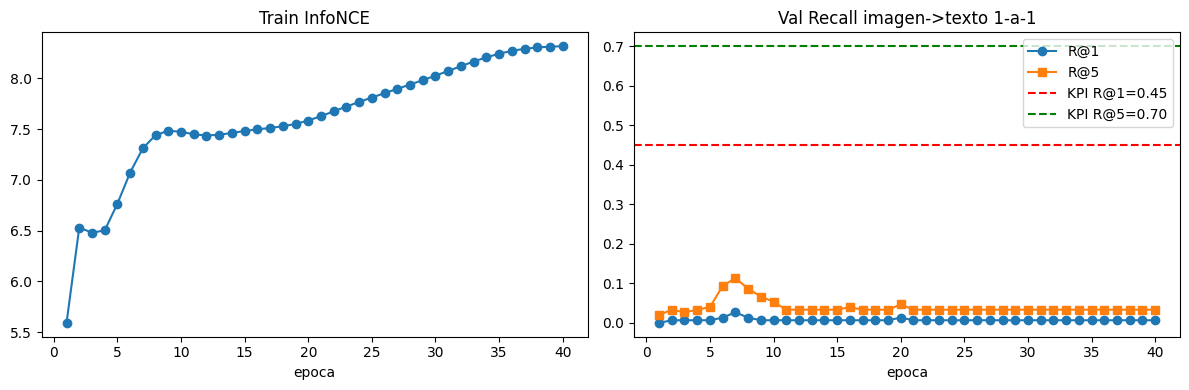

Metricas guardadas en D:\analitica\outputs_geovision\v14_retrieval_antileakage\metricas_retrieval_v14.json
Mejor val R@1 = 0.0267 (KPI >= 0.45)


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['epoch'], history['train_nce'], marker='o'); ax[0].set_title('Train InfoNCE'); ax[0].set_xlabel('epoca')
ax[1].plot(history['epoch'], history['val_r1'], marker='o', label='R@1')
ax[1].plot(history['epoch'], history['val_r5'], marker='s', label='R@5')
ax[1].axhline(0.45, ls='--', c='r', label='KPI R@1=0.45'); ax[1].axhline(0.70, ls='--', c='g', label='KPI R@5=0.70')
ax[1].set_title('Val Recall imagen->texto 1-a-1'); ax[1].set_xlabel('epoca'); ax[1].legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'curvas_retrieval_v14.png', dpi=150, bbox_inches='tight'); plt.show()

metricas = {'seed': SEED, 'batch_efectivo': BATCH_SIZE*ACCUM_STEPS,
            'unfreeze_text_layers': UNFREEZE_TEXT_LAYERS, 'temp_init': TEMP_INIT,
            'memory_bank': MEMORY_BANK_SIZE, 'mejor_val_r1': best_r1,
            'kpi_r1': 0.45, 'kpi_r5': 0.70, 'historia': dict(history)}
with open(OUTPUT_DIR / 'metricas_retrieval_v14.json', 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print('Metricas guardadas en', OUTPUT_DIR / 'metricas_retrieval_v14.json')
print(f"Mejor val R@1 = {best_r1:.4f} (KPI >= 0.45)")
